In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Read in accession idents

In [2]:
atta_df = pd.read_csv("../../data/combined.table3.w_biome.csv")

In [3]:
atta_df.head()

,accession,assembly_f_unweighted,assembly_f_weighted,assembly_f_readmapped,assembly_f_readmapped_w,ref_f_unweighted,ref_f_weighted,f_reads_mapped,assembly_refmap_isect_w,yaml_n_bases,...,yaml_total_hashes,w_isect_all,w_isect_matches,w_no_isect,w_isect_mapassem,w_mapassem_only,w_map_only,biome1,biome2,biome3
0,DRR014782,0.276438,0.844373,0.423639,0.882288,0.536980,0.868853,0.905193,0.798369,8349341510,...,955250,4684098,5097643,348903,4954008,5176463,4755920,Host-associated,Host-associated:Mammals,Host-associated:Mammals:Respiratory system
1,DRR014785,0.274877,0.831528,0.440818,0.876726,0.551175,0.863483,0.904628,0.783335,9188299904,...,1139941,5065218,5583479,383222,5376845,5669111,5169584,Host-associated,Host-associated:Mammals,Host-associated:Mammals:Respiratory system
2,DRR121397,0.137995,0.213100,0.265707,0.325096,0.110249,0.153467,0.371231,0.083111,1346724223,...,876945,97524,180080,733798,250052,381472,121939,Host-associated,Host-associated:Plants,Host-associated:Plants:Root
3,DRR121401,0.113473,0.164884,0.218902,0.261716,0.084405,0.107862,0.288395,0.051769,1106773348,...,806494,50219,104632,676865,159941,253878,65327,Host-associated,Host-associated:Plants,Host-associated:Plants:Root
4,ERR10695318,0.090915,0.921021,0.921988,0.995351,0.053441,0.748644,0.859269,0.746619,21495510640,...,932896,12893990,12928956,70996,15905879,17189561,12919671,Engineered,Engineered:Food production,Engineered:Food production:Dairy products


In [4]:
print(f"{len(atta_df['accession'])} total accessions in file.\n\n{atta_df['accession'].head().to_string()}\n...\n{atta_df['accession'].tail().to_string()}")

84 total accessions in file.

0      DRR014782
1      DRR014785
2      DRR121397
3      DRR121401
4    ERR10695318
...
79    SRR7610133
80    SRR9109404
81    SRR9182858
82    SRR9182859
83     SRR975540


# Read in saturation data

In [5]:
#with open('../data/wort-sra-signature-saturation-report.txt', 'r') as fp:
#    while True:
#        line = fp.readline()
#        if not line:
#            break  # Stop when end of file is reached
#        print(line.strip())
print(open('/Users/ZYZhao/projects/AL/onek/2025-metagenome-sample-saturation-jean/data/wort-sra-signature-saturation-report.txt', 'r').read())

SOURMASH SATURATION PROCESSING REPORT

Generated: 2025-12-05 01:14:30

PARAMETERS:
--------------------------------------------------------------------------------
K-mer size: 31
Molecule type: None
Saturation threshold: 0

SUMMARY STATISTICS:
--------------------------------------------------------------------------------
Total files to process: 5150028
Files completed: 5150011
Files skipped (already processed): 5149985
Results written (above threshold): 0
Files below threshold: 0
Files with errors: 26
Files missing/unaccounted: 17

Success rate: 100.00%


ERROR DETAILS:
Total errors: 26

1. /group/ctbrowngrp/irber/data/wort-data/wort-sra/sigs/ERR5751998.sig: Error while reading signatures from '/group/ctbrowngrp/irber/data/wort-data/wort-sra/sigs/SRR13867090.sig'.
2. /group/ctbrowngrp/irber/data/wort-data/wort-sra/sigs/SRR18132371.sig: Error while reading signatures from '/group/ctbrowngrp/irber/data/wort-data/wort-sra/sigs/SRR25783207.sig'.
3. /group/ctbrowngrp/irber/data/wort-data/

In [5]:
sat_df = pd.read_csv('../../data/wort-sra-signature-saturation.csv')

In [6]:
sat_df.head()

,filepath,signature,novel_count,total_count,sequence_saturation
0,/group/ctbrowngrp/irber/data/wort-data/wort-sr...,SRR33867156,23507,397539,0.940869
1,/group/ctbrowngrp/irber/data/wort-data/wort-sr...,ERR4022268,27896,308529,0.909584
2,/group/ctbrowngrp/irber/data/wort-data/wort-sr...,ERR3771976,223,3174,0.929742
3,/group/ctbrowngrp/irber/data/wort-data/wort-sr...,ERR11996469,20,40,0.500000
4,/group/ctbrowngrp/irber/data/wort-data/wort-sr...,ERR10755277,3185,26976,0.881932


In [7]:
len(sat_df[sat_df['total_count'] <= 0])

24468

# Intersect the dataframes

In [15]:
merged_df = pd.merge(atta_df, sat_df, left_on="accession", right_on="signature", how='inner')
df = merged_df[["accession", "assembly_f_weighted", "novel_count", "total_count", "sequence_saturation", "biome1", "biome2", "biome3"]]

# Save to CSV
df.to_csv("../../data/assembly_saturation_merged.csv", index=False)

# Optional: check how many matched
print("Matched samples:", df.shape[0])

Matched samples: 84


In [9]:
df.head()

,accession,assembly_f_weighted,novel_count,total_count,sequence_saturation,biome1,biome2,biome3
0,DRR014782,0.844373,1006063,5987910,0.831984,Host-associated,Host-associated:Mammals,Host-associated:Mammals:Respiratory system
1,DRR014785,0.831528,1202281,6611355,0.818149,Host-associated,Host-associated:Mammals,Host-associated:Mammals:Respiratory system
2,DRR121397,0.213100,913035,1179091,0.225645,Host-associated,Host-associated:Plants,Host-associated:Plants:Root
3,DRR121401,0.164884,826324,972362,0.150189,Host-associated,Host-associated:Plants,Host-associated:Plants:Root
4,ERR10695318,0.921021,969796,17278385,0.943872,Engineered,Engineered:Food production,Engineered:Food production:Dairy products


In [10]:
len(df[df['total_count'] <= 10])

0

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
assembly_f_weighted,84.0,6.061301e-01,2.871364e-01,0.017167,3.582651e-01,6.952672e-01,8.448083e-01,9.703229e-01
novel_count,84.0,1.320536e+06,1.462924e+06,11424.000000,3.561908e+05,9.162920e+05,1.773549e+06,1.020992e+07
total_count,84.0,4.771270e+06,4.485356e+06,13652.000000,1.515332e+06,3.491203e+06,6.694086e+06,2.165633e+07
sequence_saturation,84.0,6.239097e-01,2.603574e-01,0.116380,4.124362e-01,6.573663e-01,8.521520e-01,9.740286e-01


In [12]:
# Find rows in atta_df that DON'T have a match in sat_df
removed = atta_df[~atta_df['accession'].isin(sat_df['signature'])]
removed

,accession,assembly_f_unweighted,assembly_f_weighted,assembly_f_readmapped,assembly_f_readmapped_w,ref_f_unweighted,ref_f_weighted,f_reads_mapped,assembly_refmap_isect_w,yaml_n_bases,...,yaml_total_hashes,w_isect_all,w_isect_matches,w_no_isect,w_isect_mapassem,w_mapassem_only,w_map_only,biome1,biome2,biome3


No obvious reason these ones are missing from `wort`:
- https://www.ncbi.nlm.nih.gov/sra/ERR3341563
- https://www.ncbi.nlm.nih.gov/sra/SRR14836544

# Plot the data

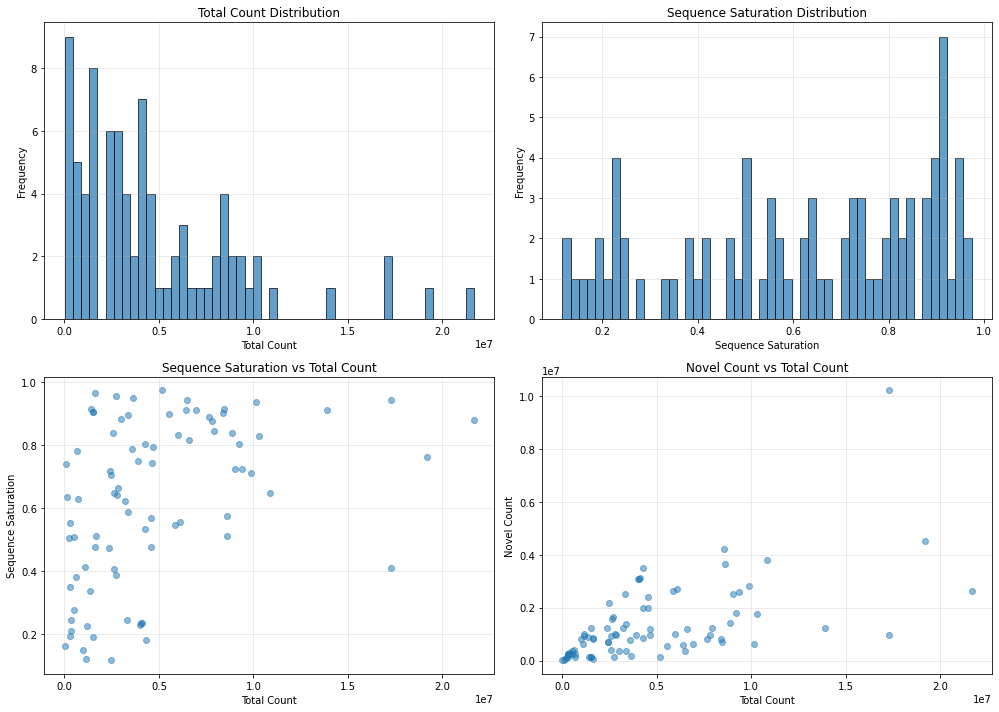

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['total_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Total Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Total Count Distribution')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(df['sequence_saturation'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Sequence Saturation')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Sequence Saturation Distribution')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(df['total_count'], df['sequence_saturation'], alpha=0.5)
axes[1, 0].set_xlabel('Total Count')
axes[1, 0].set_ylabel('Sequence Saturation')
axes[1, 0].set_title('Sequence Saturation vs Total Count')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(df['total_count'], df['novel_count'], alpha=0.5)
axes[1, 1].set_xlabel('Total Count')
axes[1, 1].set_ylabel('Novel Count')
axes[1, 1].set_title('Novel Count vs Total Count')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

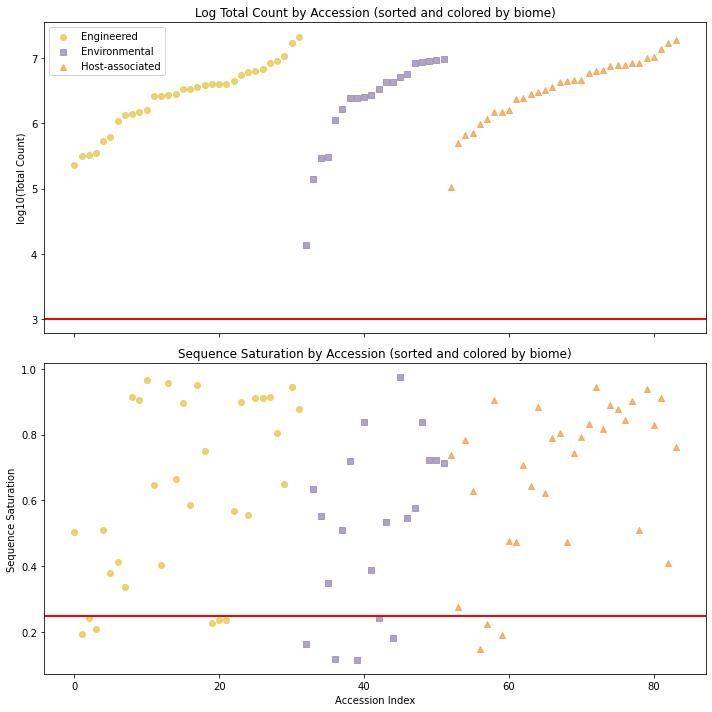

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../../data/assembly_saturation_merged.csv")

# Sort by biome, then optionally by total_count (within biome)
df = df.sort_values(["biome1", "total_count"]).reset_index(drop=True)

# Create index for plotting
df["index"] = range(len(df))

# Log10 total count
df["log_total_count"] = np.log10(df["total_count"])

# Color map by biome
biome_colors = {
    "Engineered": "#e6c84f",
    "Environmental": "#9c8db5",
    "Host-associated": "#f0a34f"
}

markers = {
    "Engineered": "o",
    "Environmental": "s",
    "Host-associated": "^"
}

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# --- Panel 1: Log Total Count ---
for biome in df["biome1"].unique():
    sub = df[df["biome1"] == biome]
    axes[0].scatter(
        sub["index"],
        sub["log_total_count"],
        label=biome,
        color=biome_colors.get(biome, "gray"),
        marker=markers.get(biome, "o"),
        alpha=0.8
    )

axes[0].set_ylabel("log10(Total Count)")
axes[0].set_title("Log Total Count by Accession (sorted and colored by biome)")
axes[0].axhline(3, color="red", linewidth=2)  # threshold like example
axes[0].legend()

# --- Panel 2: Sequence Saturation ---
for biome in df["biome1"].unique():
    sub = df[df["biome1"] == biome]
    axes[1].scatter(
        sub["index"],
        sub["sequence_saturation"],
        label=biome,
        color=biome_colors.get(biome, "gray"),
        marker=markers.get(biome, "o"),
        alpha=0.8
    )

axes[1].set_ylabel("Sequence Saturation")
axes[1].set_xlabel("Accession Index")
axes[1].set_title("Sequence Saturation by Accession (sorted and colored by biome)")
axes[1].axhline(0.25, color="red", linewidth=2)  # threshold like example

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../../data/assembly_saturation_merged.csv")

# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(
    df["assembly_f_weighted"],
    df["sequence_saturation"]
)

# Spearman correlation (rank-based, more robust)
spearman_rho, spearman_p = stats.spearmanr(
    df["assembly_f_weighted"],
    df["sequence_saturation"]
)

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman rho = {spearman_rho:.3f}, p = {spearman_p:.3e}")


Pearson r = 0.935, p = 9.606e-39
Spearman rho = 0.951, p = 1.279e-43


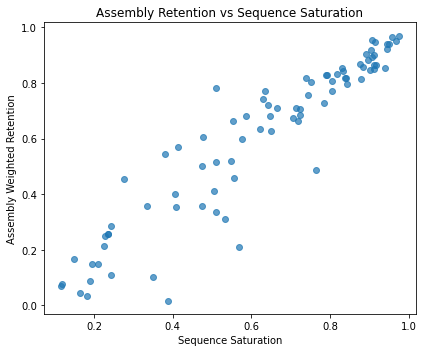

In [18]:
plt.figure(figsize=(6,5))
plt.scatter(df["sequence_saturation"], df["assembly_f_weighted"], alpha=0.7)

plt.xlabel("Sequence Saturation")
plt.ylabel("Assembly Weighted Retention")
plt.title("Assembly Retention vs Sequence Saturation")

plt.tight_layout()
plt.show()

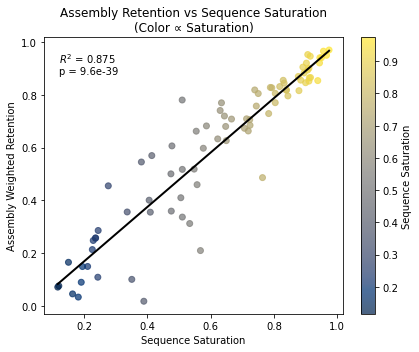

In [19]:
plt.figure(figsize=(6,5))

sc = plt.scatter(
    df["sequence_saturation"],
    df["assembly_f_weighted"],
    c=df["sequence_saturation"],   # color by saturation
    cmap="cividis",                # different from plasma & viridis
    alpha=0.7
)

plt.xlabel("Sequence Saturation")
plt.ylabel("Assembly Weighted Retention")
plt.title("Assembly Retention vs Sequence Saturation\n(Color ∝ Saturation)")

# Optional regression
from scipy import stats
x = df["sequence_saturation"]
y = df["assembly_f_weighted"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color="black", linewidth=2)

plt.text(
    0.05, 0.95,
    f"$R^2$ = {r_squared:.3f}\np = {p_value:.1e}",
    transform=plt.gca().transAxes,
    va="top"
)

cbar = plt.colorbar(sc)
cbar.set_label("Sequence Saturation")

plt.tight_layout()
plt.show()

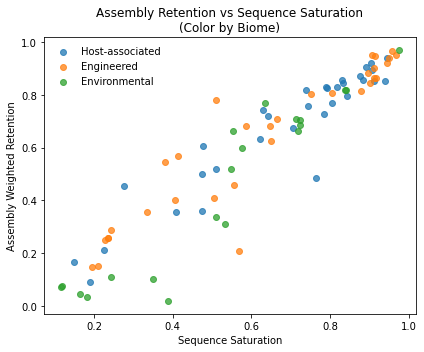

In [20]:
plt.figure(figsize=(6,5))

# Define biome color mapping
biome_colors = {
    'Environmental': '#2ca02c',
    'Engineered': '#ff7f0e',
    'Host-associated': '#1f77b4'
}

# Plot each biome separately
for biome in df["biome1"].unique():
    sub = df[df["biome1"] == biome]
    plt.scatter(
        sub["sequence_saturation"],
        sub["assembly_f_weighted"],
        alpha=0.75,
        label=biome
    )

plt.xlabel("Sequence Saturation")
plt.ylabel("Assembly Weighted Retention")
plt.title("Assembly Retention vs Sequence Saturation\n(Color by Biome)")

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

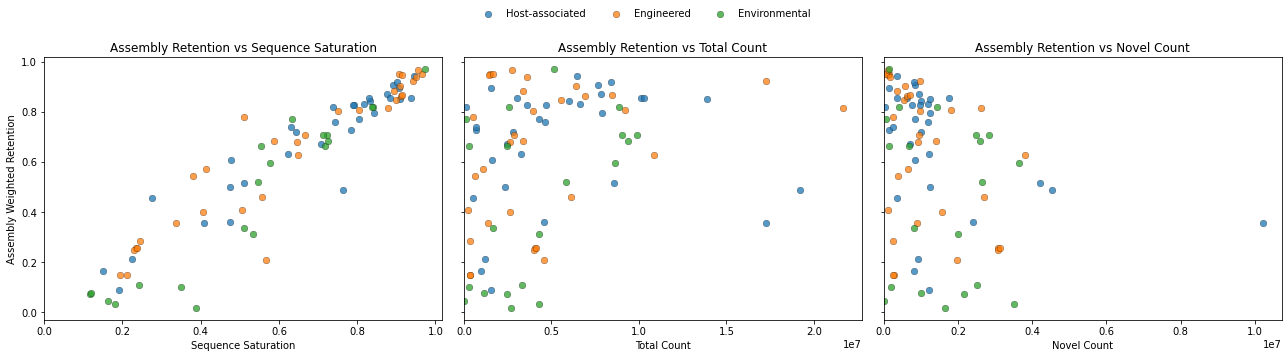

In [21]:
biome_colors = {
    'Environmental': '#2ca02c',
    'Engineered': '#ff7f0e',
    'Host-associated': '#1f77b4'
}

biome_order = ["Host-associated", "Engineered", "Environmental"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

panels = [
    ("sequence_saturation", "Sequence Saturation"),
    ("total_count", "Total Count"),
    ("novel_count", "Novel Count"),
]

for ax, (xcol, xlabel) in zip(axes, panels):
    for biome in biome_order:
        sub = df[df["biome1"] == biome]
        ax.scatter(
            sub[xcol],
            sub["assembly_f_weighted"],
            color=biome_colors.get(biome, "gray"),
            alpha=0.75,
            s=45,
            edgecolor='black',
            linewidth=0.3,
            label=biome
        )

    ax.set_xlim(left=0)   # Force x-axis to start at 0
    ax.set_xlabel(xlabel)
    ax.set_title(f"Assembly Retention vs {xlabel}")

axes[0].set_ylabel("Assembly Weighted Retention")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:3], labels[:3], frameon=False, loc="upper center", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

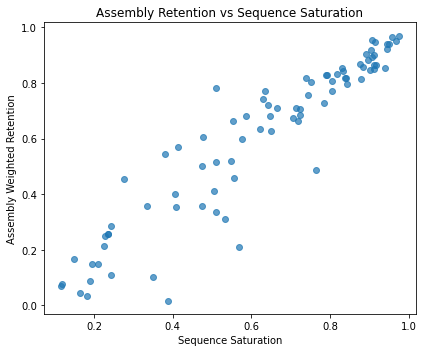

In [22]:
plt.figure(figsize=(6,5))
plt.scatter(df["sequence_saturation"], df["assembly_f_weighted"], alpha=0.7)

plt.xlabel("Sequence Saturation")
plt.ylabel("Assembly Weighted Retention")
plt.title("Assembly Retention vs Sequence Saturation")

plt.tight_layout()
plt.show()

In [23]:
for biome in df["biome1"].unique():
    sub = df[df["biome1"] == biome]
    r, p = stats.spearmanr(sub["assembly_f_weighted"], sub["sequence_saturation"])
    print(f"{biome}: rho={r:.3f}, p={p:.3e}")


Host-associated: rho=0.940, p=1.405e-15
Engineered: rho=0.944, p=5.572e-16
Environmental: rho=0.925, p=5.539e-09


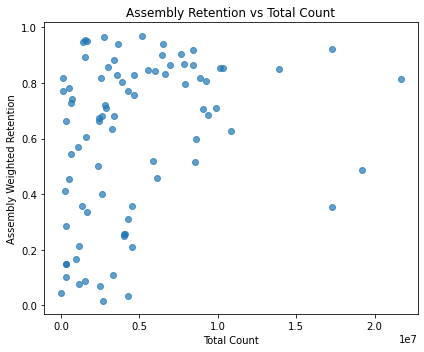

In [24]:
plt.figure(figsize=(6,5))
plt.scatter(df["total_count"], df["assembly_f_weighted"], alpha=0.7)

plt.xlabel("Total Count")
plt.ylabel("Assembly Weighted Retention")
plt.title("Assembly Retention vs Total Count")

plt.tight_layout()
plt.show()

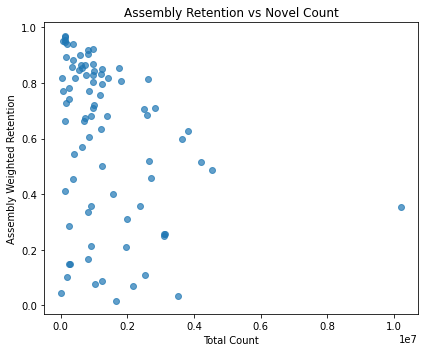

In [25]:
plt.figure(figsize=(6,5))
plt.scatter(df["novel_count"], df["assembly_f_weighted"], alpha=0.7)

plt.xlabel("Total Count")
plt.ylabel("Assembly Weighted Retention")
plt.title("Assembly Retention vs Novel Count")

plt.tight_layout()
plt.show()

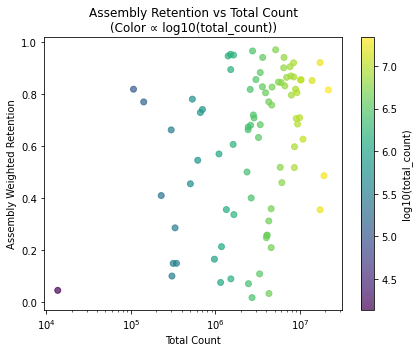

In [26]:
plt.figure(figsize=(6,5))

# Log-transform total_count for color scaling
log_total = np.log10(df["total_count"])

sc = plt.scatter(
    df["total_count"],
    df["assembly_f_weighted"],
    c=log_total,      # color by total_count
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Total Count")
plt.ylabel("Assembly Weighted Retention")
plt.title("Assembly Retention vs Total Count\n(Color ∝ log10(total_count))")

# Optional but recommended: log-scale x-axis
plt.xscale("log")

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label("log10(total_count)")

plt.tight_layout()
plt.show()

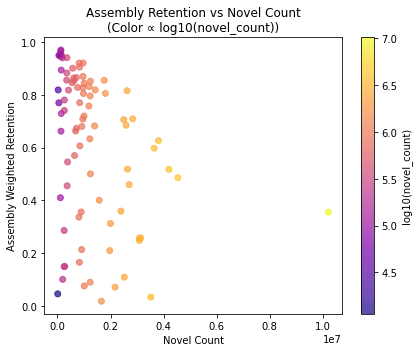

In [27]:
plt.figure(figsize=(6,5))

# Log-transform novel_count for better color scaling
log_novel = np.log10(df["novel_count"])

sc = plt.scatter(
    df["novel_count"],
    df["assembly_f_weighted"],
    c=log_novel,          # color by novel_count
    cmap="plasma",        # different from viridis
    alpha=0.7
)

plt.xlabel("Novel Count")
plt.ylabel("Assembly Weighted Retention")
plt.title("Assembly Retention vs Novel Count\n(Color ∝ log10(novel_count))")

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label("log10(novel_count)")

plt.tight_layout()
plt.show()

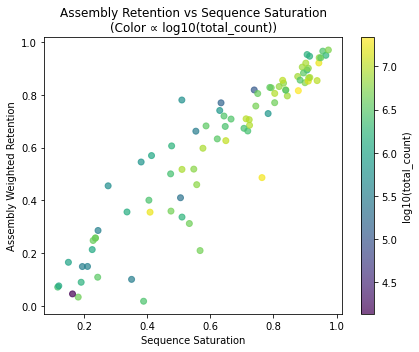

In [28]:
plt.figure(figsize=(6,5))

sc = plt.scatter(
    df["sequence_saturation"],
    df["assembly_f_weighted"],
    c=np.log10(df["total_count"]),
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Sequence Saturation")
plt.ylabel("Assembly Weighted Retention")
plt.title("Assembly Retention vs Sequence Saturation\n(Color ∝ log10(total_count))")

plt.colorbar(sc, label="log10(total_count)")

plt.tight_layout()
plt.show()

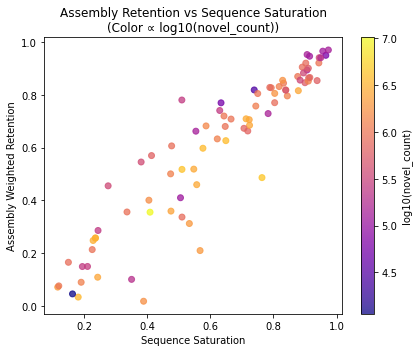

In [29]:
log_novel = np.log10(df["novel_count"])

plt.figure(figsize=(6,5))

sc = plt.scatter(
    df["sequence_saturation"],
    df["assembly_f_weighted"],
    c=log_novel,
    cmap="plasma",   # novel_count = plasma (different palette)
    alpha=0.75
)

plt.xlabel("Sequence Saturation")
plt.ylabel("Assembly Weighted Retention")
plt.title("Assembly Retention vs Sequence Saturation\n(Color ∝ log10(novel_count))")

cbar = plt.colorbar(sc)
cbar.set_label("log10(novel_count)")

plt.tight_layout()
plt.show()

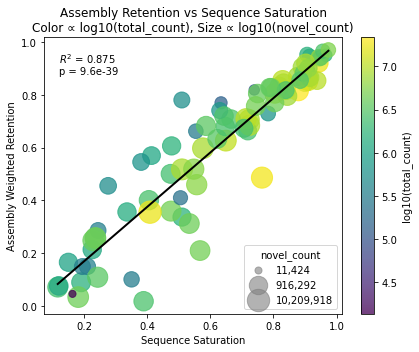

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- Prep ---
# Log-transform for color and size encodings
log_total = np.log10(df["total_count"])
log_novel = np.log10(df["novel_count"])

# Normalize log_novel to [0,1] then scale to a visible marker-area range
norm = (log_novel - log_novel.min()) / (log_novel.max() - log_novel.min())
sizes = 50 + norm * 450   # marker areas between 50 and 500 (tweak if desired)

# --- Plot ---
plt.figure(figsize=(6, 5))

sc = plt.scatter(
    df["sequence_saturation"],
    df["assembly_f_weighted"],
    s=sizes,
    c=log_total,
    cmap="viridis",
    alpha=0.75
)

# Linear regression line
x = df["sequence_saturation"].values
y = df["assembly_f_weighted"].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color="black", linewidth=2)

# Labels and title
plt.xlabel("Sequence Saturation")
plt.ylabel("Assembly Weighted Retention")
plt.title("Assembly Retention vs Sequence Saturation\nColor ∝ log10(total_count), Size ∝ log10(novel_count)")

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label("log10(total_count)")

# Annotate R^2 and p-value
plt.text(
    0.05, 0.95,
    f"$R^2$ = {r_squared:.3f}\np = {p_value:.1e}",
    transform=plt.gca().transAxes,
    va="top"
)

# --- Size legend (novel_count) ---
# Choose representative values (min, median, max)
vals = [df["novel_count"].min(), df["novel_count"].median(), df["novel_count"].max()]
labels = [f"{int(v):,}" for v in vals]

# Convert those values to the same size scale used above
def size_from_value(v):
    lv = np.log10(v)
    n = (lv - log_novel.min()) / (log_novel.max() - log_novel.min())
    return 50 + n * 450

handles = [
    plt.scatter([], [], s=size_from_value(v), color="gray", alpha=0.6)
    for v in vals
]
plt.legend(handles, labels, title="novel_count", loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

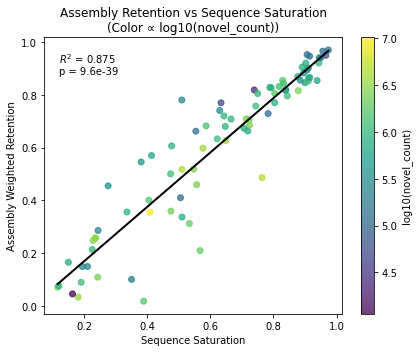

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.figure(figsize=(6,5))

# Log-transform novel_count for smoother color scaling
log_novel = np.log10(df["novel_count"])

# Scatter plot with color encoding
sc = plt.scatter(
    df["sequence_saturation"],
    df["assembly_f_weighted"],
    c=log_novel,
    cmap="viridis",
    alpha=0.75
)

# Linear regression
x = df["sequence_saturation"].values
y = df["assembly_f_weighted"].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept

plt.plot(x_line, y_line, color="black", linewidth=2)

# Annotate R²
plt.text(
    0.05, 0.95,
    f"$R^2$ = {r_squared:.3f}\np = {p_value:.1e}",
    transform=plt.gca().transAxes,
    verticalalignment='top'
)

plt.xlabel("Sequence Saturation")
plt.ylabel("Assembly Weighted Retention")
plt.title("Assembly Retention vs Sequence Saturation\n(Color ∝ log10(novel_count))")

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label("log10(novel_count)")

plt.tight_layout()
plt.show()


<Figure size 1008x432 with 0 Axes>

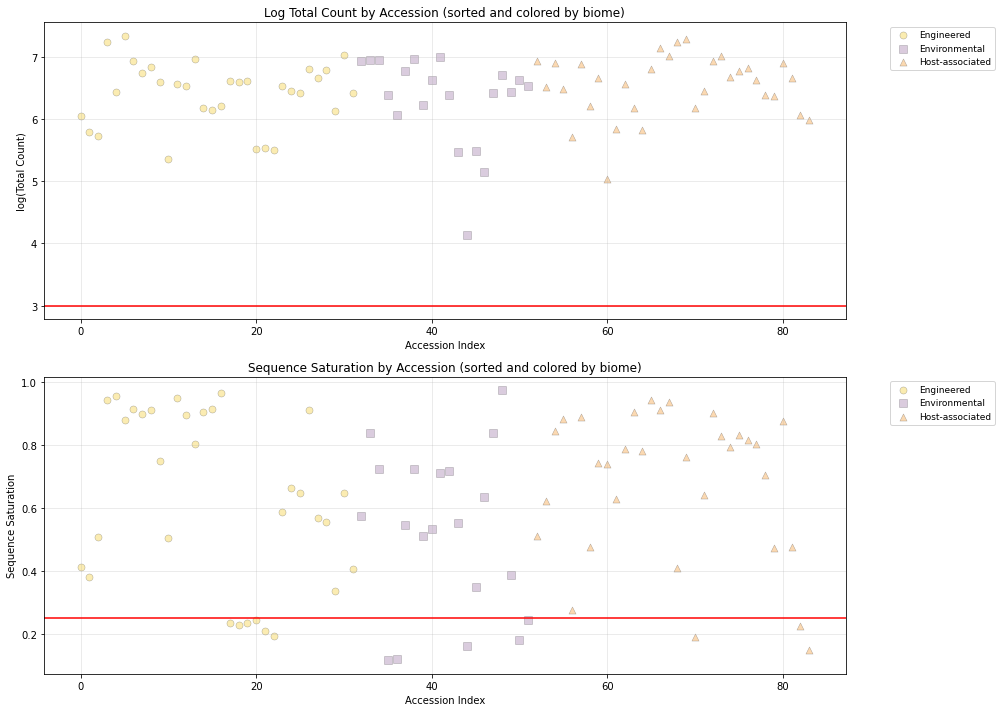

In [32]:
df_sorted = df.sort_values(['biome1', 'biome2', 'biome3'])

biome_column = 'biome1'
plt.figure(figsize=(14, 6))

unique_biomes = df_sorted[biome_column].unique()

# Kelly's 20 maximally distinct colors + additional computed colors
# https://david-barnett.github.io/microViz/reference/distinct_palette.html
color_palette = [
    '#f3c300', '#875692', '#f38400', '#a1caf1', '#be0032',
    '#c2b280', '#848482', '#008856', '#e68fac', '#0067a5',
    '#f99379', '#604e97', '#f6a600', '#b3446c', '#dcd300',
    '#882d17', '#8db600', '#654522', '#e25822', '#2b3d26',
    '#d3d3d3', '#ffffff', '#000000'  # lightgrey, white, black
]

# Extend palette if needed by repeating colors
if len(unique_biomes) > len(color_palette):
    color_palette = color_palette * (len(unique_biomes) // len(color_palette) + 1)

colors = color_palette[:len(unique_biomes)]

markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'H', 'X', 'd', 'P', 'h', '8']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

#start log total count plot
for i, (biome, color) in enumerate(zip(unique_biomes, colors)):
    mask = df_sorted[biome_column] == biome
    indices = np.where(mask)[0]
    marker = markers[i % len(markers)]
    
    ax1.scatter(indices, 
               np.log10(df_sorted[mask]['total_count']),
               label=biome, 
               alpha=0.3, 
               color=color,
               s=50,
               marker=marker,
               edgecolors='black',
               linewidth=0.5)

ax1.axhline(y=np.log10(1000), color='red')
ax1.set_xlabel('Accession Index')
ax1.set_ylabel('log(Total Count)')
ax1.set_title('Log Total Count by Accession (sorted and colored by biome)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# start seq sat plot
for i, (biome, color) in enumerate(zip(unique_biomes, colors)):
    mask = df_sorted[biome_column] == biome
    indices = np.where(mask)[0]
    marker = markers[i % len(markers)]
    
    ax2.scatter(indices, 
               df_sorted[mask]['sequence_saturation'], 
               label=biome, 
               alpha=0.3, 
               color=color,
               s=50,
               marker=marker,
               edgecolors='black',
               linewidth=0.5)

ax2.axhline(y=0.25, color='red')
ax2.set_xlabel('Accession Index')
ax2.set_ylabel('Sequence Saturation')
ax2.set_title('Sequence Saturation by Accession (sorted and colored by biome)')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1008x432 with 0 Axes>

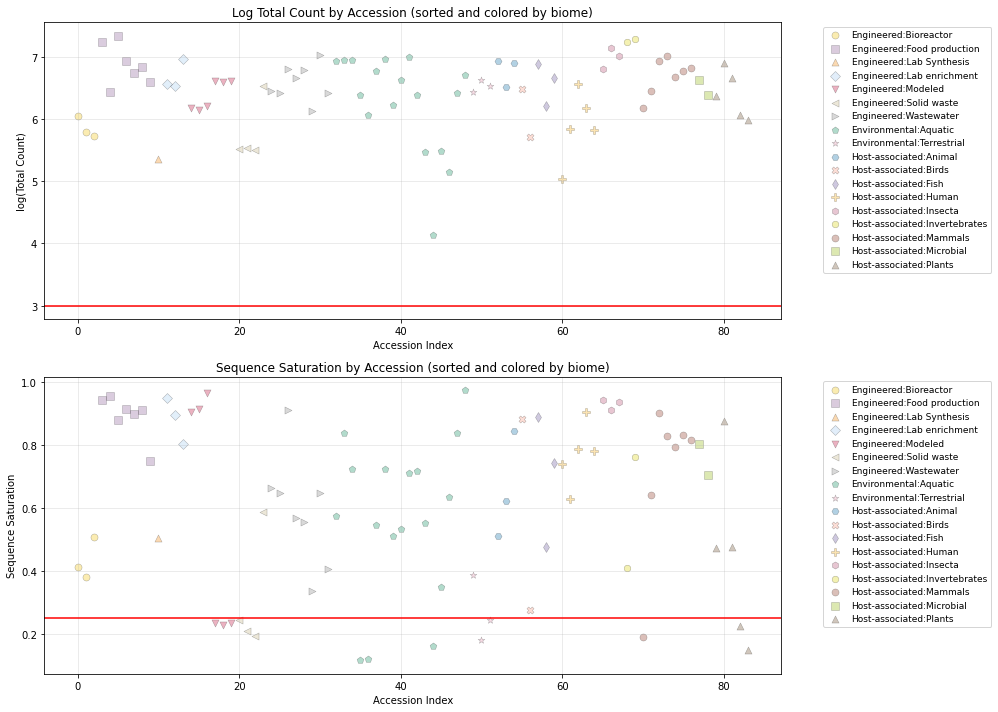

In [33]:
df_sorted = df.sort_values(['biome1', 'biome2', 'biome3'])

biome_column = 'biome2'
plt.figure(figsize=(14, 6))

unique_biomes = df_sorted[biome_column].unique()

# Kelly's 20 maximally distinct colors + additional computed colors
# https://david-barnett.github.io/microViz/reference/distinct_palette.html
color_palette = [
    '#f3c300', '#875692', '#f38400', '#a1caf1', '#be0032',
    '#c2b280', '#848482', '#008856', '#e68fac', '#0067a5',
    '#f99379', '#604e97', '#f6a600', '#b3446c', '#dcd300',
    '#882d17', '#8db600', '#654522', '#e25822', '#2b3d26',
    '#d3d3d3', '#ffffff', '#000000'  # lightgrey, white, black
]

# Extend palette if needed by repeating colors
if len(unique_biomes) > len(color_palette):
    color_palette = color_palette * (len(unique_biomes) // len(color_palette) + 1)

colors = color_palette[:len(unique_biomes)]

markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'H', 'X', 'd', 'P', 'h', '8']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

#start log total count plot
for i, (biome, color) in enumerate(zip(unique_biomes, colors)):
    mask = df_sorted[biome_column] == biome
    indices = np.where(mask)[0]
    marker = markers[i % len(markers)]
    
    ax1.scatter(indices, 
               np.log10(df_sorted[mask]['total_count']),
               label=biome, 
               alpha=0.3, 
               color=color,
               s=50,
               marker=marker,
               edgecolors='black',
               linewidth=0.5)

ax1.axhline(y=np.log10(1000), color='red')
ax1.set_xlabel('Accession Index')
ax1.set_ylabel('log(Total Count)')
ax1.set_title('Log Total Count by Accession (sorted and colored by biome)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# start seq sat plot
for i, (biome, color) in enumerate(zip(unique_biomes, colors)):
    mask = df_sorted[biome_column] == biome
    indices = np.where(mask)[0]
    marker = markers[i % len(markers)]
    
    ax2.scatter(indices, 
               df_sorted[mask]['sequence_saturation'], 
               label=biome, 
               alpha=0.3, 
               color=color,
               s=50,
               marker=marker,
               edgecolors='black',
               linewidth=0.5)

ax2.axhline(y=0.25, color='red')
ax2.set_xlabel('Accession Index')
ax2.set_ylabel('Sequence Saturation')
ax2.set_title('Sequence Saturation by Accession (sorted and colored by biome)')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1008x432 with 0 Axes>

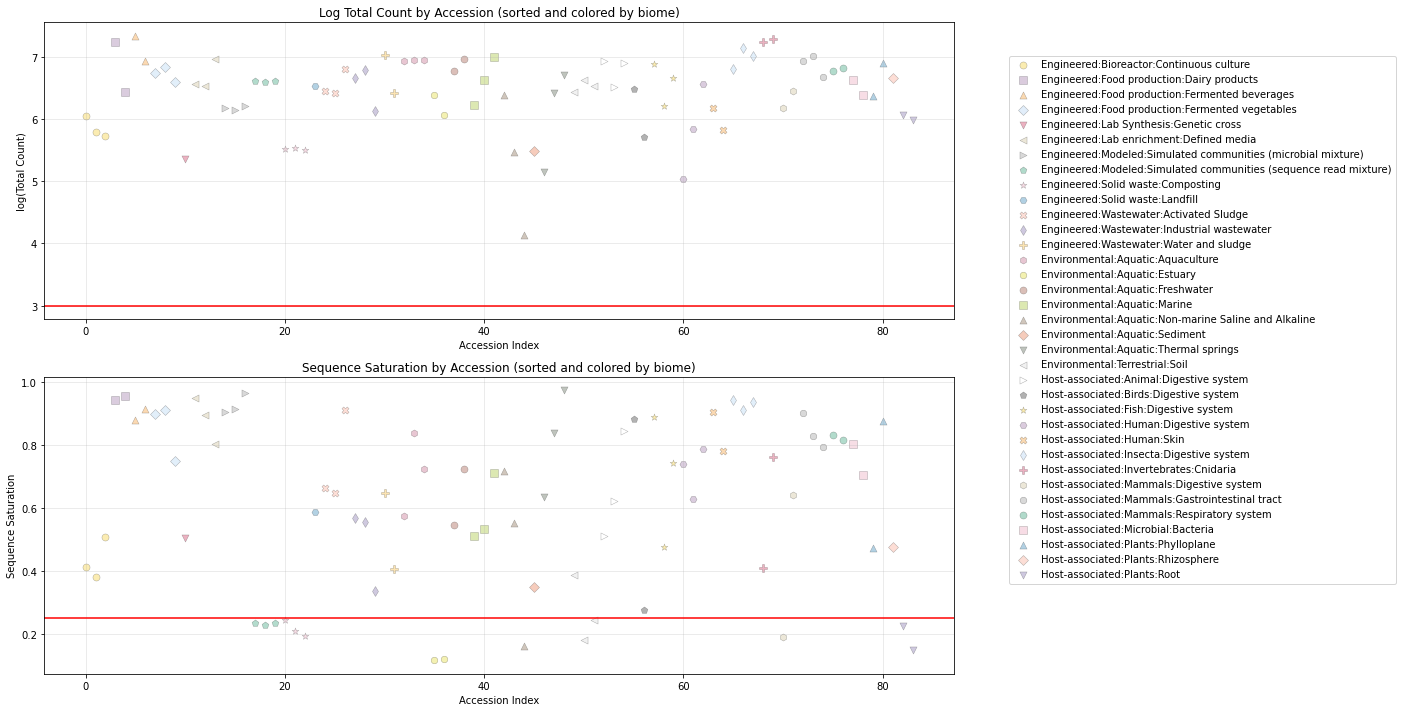

In [34]:
df_sorted = df.sort_values(['biome1', 'biome2', 'biome3'])

biome_column = 'biome3'
plt.figure(figsize=(14, 6))

unique_biomes = df_sorted[biome_column].unique()

# Kelly's 20 maximally distinct colors + additional computed colors
# https://david-barnett.github.io/microViz/reference/distinct_palette.html
color_palette = [
    '#f3c300', '#875692', '#f38400', '#a1caf1', '#be0032',
    '#c2b280', '#848482', '#008856', '#e68fac', '#0067a5',
    '#f99379', '#604e97', '#f6a600', '#b3446c', '#dcd300',
    '#882d17', '#8db600', '#654522', '#e25822', '#2b3d26',
    '#d3d3d3', '#ffffff', '#000000'  # lightgrey, white, black
]

# Extend palette if needed by repeating colors
if len(unique_biomes) > len(color_palette):
    color_palette = color_palette * (len(unique_biomes) // len(color_palette) + 1)

colors = color_palette[:len(unique_biomes)]

markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'H', 'X', 'd', 'P', 'h', '8']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
handles = []
labels = []

# Plot 1: Log Total Count
for i, (biome, color) in enumerate(zip(unique_biomes, colors)):
    mask = df_sorted[biome_column] == biome
    indices = np.where(mask)[0]
    marker = markers[i % len(markers)]
    
    scatter = ax1.scatter(indices, 
                         np.log10(df_sorted[mask]['total_count']),
                         alpha=0.3, 
                         color=color,
                         s=50,
                         marker=marker,
                         edgecolors='black',
                         linewidth=0.5)
    
    # Collect handles and labels only once
    if i < len(unique_biomes):
        handles.append(scatter)
        labels.append(biome)

ax1.axhline(y=np.log10(1000), color='red')
ax1.set_xlabel('Accession Index')
ax1.set_ylabel('log(Total Count)')
ax1.set_title('Log Total Count by Accession (sorted and colored by biome)')
ax1.grid(True, alpha=0.3)

# Plot 2: Sequence Saturation (no legend)
for i, (biome, color) in enumerate(zip(unique_biomes, colors)):
    mask = df_sorted[biome_column] == biome
    indices = np.where(mask)[0]
    marker = markers[i % len(markers)]
    
    ax2.scatter(indices, 
               df_sorted[mask]['sequence_saturation'], 
               alpha=0.3, 
               color=color,
               s=50,
               marker=marker,
               edgecolors='black',
               linewidth=0.5)

ax2.axhline(y=0.25, color='red')
ax2.set_xlabel('Accession Index')
ax2.set_ylabel('Sequence Saturation')
ax2.set_title('Sequence Saturation by Accession (sorted and colored by biome)')
ax2.grid(True, alpha=0.3)

# Add single legend to the figure (positioned on the right)
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.55), fontsize=10)

plt.tight_layout()
plt.subplots_adjust(right=0.95)
plt.show()